## Вторая Лаба по Анализу Данных. Ниже я сделаю вновь старую структуру

In [2]:
library(tidyverse)

freq_data <- read_csv("D:/my_projects/AD/freMTPL2freq.csv", show_col_types = FALSE)
sev_data <- read_csv("D:/my_projects/AD/freMTPL2sev.csv", show_col_types = FALSE)

sev_data_clean <- sev_data %>% distinct()

sev_aggregated <- sev_data_clean %>%
  group_by(IDpol) %>%
  summarise(Total_Claim_Amount = sum(ClaimAmount), .groups = 'drop')

full_data <- freq_data %>%
  left_join(sev_aggregated, by = "IDpol") %>%
  mutate(
    Total_Claim_Amount = replace_na(Total_Claim_Amount, 0),
    Exposure = if_else(Exposure > 1, 1, Exposure),
    VehBrand = as.factor(VehBrand),
    VehGas = as.factor(VehGas),
    Region = as.factor(Region),
    Area = as.factor(Area)
  ) %>%
  filter(!(ClaimNb == 0 & Total_Claim_Amount > 0)) %>%
  filter(!(ClaimNb > 0 & Total_Claim_Amount == 0))

claims_only <- full_data %>% filter(Total_Claim_Amount > 0)

claims_classified <- claims_only %>%
  mutate(
    Claim_Type = if_else(round(Total_Claim_Amount, 2) %in% c(1204, 1128, 1172), 
                         "Фіксовані суми (Аномалія)", 
                         "Індивідуальні аварії (Норма)")
  )

age_sev <- claims_only %>%
  group_by(DrivAge) %>%
  summarise(
    Avg_Claim = mean(Total_Claim_Amount),
    Count = n(),
    .groups = 'drop'
  ) %>%
  filter(Count > 5)

individual_claims <- claims_classified %>% 
  filter(Claim_Type == "Індивідуальні аварії (Норма)")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [10]:
threshold_995 <- quantile(claims_only$Total_Claim_Amount, 0.995)

lab2_data <- claims_only %>%
  mutate(
    is_tariff_A = if_else(round(Total_Claim_Amount, 2) == 1204, 1, 0),
    is_tariff_B = if_else(round(Total_Claim_Amount, 2) == 1128, 1, 0),
    is_tariff_C = if_else(round(Total_Claim_Amount, 2) == 1172, 1, 0)
  )

body_claims <- lab2_data %>%
  filter(Total_Claim_Amount <= threshold_995) %>%
  mutate(log_claim = log10(Total_Claim_Amount))

tail_claims <- lab2_data %>%
  filter(Total_Claim_Amount > threshold_995)


alpha <- 0.05
z_value <- qnorm(1 - alpha/2)

cat("1. Довірчий інтервал. Геометричне середнє лог нормального тіла\n")
n_body <- nrow(body_claims)
mean_log <- mean(body_claims$log_claim)
sd_log <- sd(body_claims$log_claim)
se_mean <- sd_log / sqrt(n_body)

ci_mean_lower <- mean_log - z_value * se_mean
ci_mean_upper <- mean_log + z_value * se_mean

mean_euro <- 10^mean_log
ci_lower_euro <- 10^ci_mean_lower
ci_upper_euro <- 10^ci_mean_upper

cat(sprintf("Середній лог-збиток: %.4f (Похибка: %.4f)\n", mean_log, se_mean))
cat(sprintf("Довірчий інтервал 95%% (в логарифмах): [%.4f; %.4f]\n", ci_mean_lower, ci_mean_upper))
cat(sprintf("Довірчий інтервал 95%% (в реальних євро): [%.0f євро; %.0f євро]\n\n", ci_lower_euro, ci_upper_euro))

cat("1.1 Довірчий інтервал. Середнє арифметичне лог нормального тіла\n")

n_body <- nrow(body_claims)

mean_log <- mean(body_claims$log_claim)
sd_log <- sd(body_claims$log_claim)
var_log <- var(body_claims$log_claim)

se_mean <- sd_log / sqrt(n_body)

ci_mean_lower <- mean_log - z_value * se_mean
ci_mean_upper <- mean_log + z_value * se_mean

mean_euro <- 10^mean_log * exp((log(10)^2 * var_log) / 2)

ci_lower_euro <- 10^ci_mean_lower * exp((log(10)^2 * var_log) / 2)
ci_upper_euro <- 10^ci_mean_upper * exp((log(10)^2 * var_log) / 2)

cat(sprintf("Середній log10-збиток: %.4f\n", mean_log))
cat(sprintf("Похибка для середнього log10: %.4f\n", se_mean))

cat(sprintf(
  "95%% CI для середнього log10-збитку: [%.4f; %.4f]\n",
  ci_mean_lower,
  ci_mean_upper
))

cat(sprintf(
  "Оцінка середнього збитку: %.0f євро\n",
  mean_euro
))

cat(sprintf(
  "95%% CI для середнього збитку: [%.0f євро; %.0f євро]\n\n",
  ci_lower_euro,
  ci_upper_euro
))

cat("2. Довірчий інтервал. Дисперсія лог нормального тіла\n")

var_log <- var(body_claims$log_claim)
df <- n_body - 1

chi2_lower <- qchisq(1 - alpha/2, df = df)
chi2_upper <- qchisq(alpha/2, df = df)

ci_var_lower <- (df * var_log) / chi2_lower
ci_var_upper <- (df * var_log) / chi2_upper

cat(sprintf("Точкова оцінка дисперсії (в логарифмах): %.4f\n", var_log))
cat(sprintf("95%% CI для дисперсії: [%.4f; %.4f]\n\n", ci_var_lower, ci_var_upper))

mu_log10 <- mean_log

variance_euro <- (
  exp((log(10)^2) * var_log) - 1
) * exp(
  2 * log(10) * mu_log10 + (log(10)^2) * var_log
)

ci_var_lower_euro <- (
  exp((log(10)^2) * ci_var_lower) - 1
) * exp(
  2 * log(10) * mu_log10 + (log(10)^2) * ci_var_lower
)

ci_var_upper_euro <- (
  exp((log(10)^2) * ci_var_upper) - 1
) * exp(
  2 * log(10) * mu_log10 + (log(10)^2) * ci_var_upper
)

sd_euro <- sqrt(variance_euro)
sd_lower_euro <- sqrt(ci_var_lower_euro)
sd_upper_euro <- sqrt(ci_var_upper_euro)

cat(sprintf(
  "Точкова оцінка дисперсії (в євро^2): %.0f\n",
  variance_euro
))

cat(sprintf(
  "95%% CI для дисперсії (в євро^2): [%.0f; %.0f]\n",
  ci_var_lower_euro,
  ci_var_upper_euro
))

cat(sprintf(
  "Точкова оцінка стандартного відхилення: %.0f євро\n",
  sd_euro
))

cat(sprintf(
  "95%% CI для стандартного відхилення: [%.0f; %.0f] євро\n\n",
  sd_lower_euro,
  sd_upper_euro
))

cat("3. Довірчий інтервал. Частки франшиз\n")

n_total <- nrow(lab2_data)

p_A <- mean(lab2_data$is_tariff_A); se_A <- sqrt((p_A * (1 - p_A)) / n_total)
ci_A_lower <- p_A - z_value * se_A; ci_A_upper <- p_A + z_value * se_A

p_B <- mean(lab2_data$is_tariff_B); se_B <- sqrt((p_B * (1 - p_B)) / n_total)
ci_B_lower <- p_B - z_value * se_B; ci_B_upper <- p_B + z_value * se_B

p_C <- mean(lab2_data$is_tariff_C); se_C <- sqrt((p_C * (1 - p_C)) / n_total)
ci_C_lower <- p_C - z_value * se_C; ci_C_upper <- p_C + z_value * se_C

cat(sprintf("Франшиза А (1204 євро): Частка = %.2f%%, 95%% CI: [%.2f%%; %.2f%%]\n", p_A * 100, ci_A_lower * 100, ci_A_upper * 100))
cat(sprintf("Франшиза Б (1128 євро): Частка = %.2f%%, 95%% CI: [%.2f%%; %.2f%%]\n", p_B * 100, ci_B_lower * 100, ci_B_upper * 100))
cat(sprintf("Франшиза В (1172 євро): Частка = %.2f%%, 95%% CI: [%.2f%%; %.2f%%]\n\n", p_C * 100, ci_C_lower * 100, ci_C_upper * 100))


cat("4. Довірчий інтервал. Ймовірність екстремумів\n")

n_total_claims <- nrow(claims_only)
p_10k <- sum(claims_only$Total_Claim_Amount > 10000) / n_total_claims
p_50k <- sum(claims_only$Total_Claim_Amount > 50000) / n_total_claims

se_10k <- sqrt((p_10k * (1 - p_10k)) / n_total_claims)
se_50k <- sqrt((p_50k * (1 - p_50k)) / n_total_claims)

ci_10k_lower <- p_10k - z_value * se_10k; ci_10k_upper <- p_10k + z_value * se_10k
ci_50k_lower <- p_50k - z_value * se_50k; ci_50k_upper <- p_50k + z_value * se_50k

cat(sprintf("Ймовірність збитку > 10,000: %.2f%%, 95%% CI: [%.2f%%; %.2f%%]\n", p_10k*100, ci_10k_lower*100, ci_10k_upper*100))
cat(sprintf("Ймовірність збитку > 50,000: %.2f%%, 95%% CI: [%.2f%%; %.2f%%]\n\n", p_50k*100, ci_50k_lower*100, ci_50k_upper*100))

1. Довірчий інтервал. Геометричне середнє лог нормального тіла
Середній лог-збиток: 2.9821 (Похибка: 0.0030)
Довірчий інтервал 95% (в логарифмах): [2.9762; 2.9880]
Довірчий інтервал 95% (в реальних євро): [947 євро; 973 євро]

1.1 Довірчий інтервал. Середнє арифметичне лог нормального тіла
Середній log10-збиток: 2.9821
Похибка для середнього log10: 0.0030
95% CI для середнього log10-збитку: [2.9762; 2.9880]
Оцінка середнього збитку: 1742 євро
95% CI для середнього збитку: [1718 євро; 1765 євро]

2. Довірчий інтервал. Дисперсія лог нормального тіла
Точкова оцінка дисперсії (в логарифмах): 0.2248
95% CI для дисперсії: [0.2209; 0.2289]

Точкова оцінка дисперсії (в євро^2): 6957709
95% CI для дисперсії (в євро^2): [6614677; 7326434]
Точкова оцінка стандартного відхилення: 2638 євро
95% CI для стандартного відхилення: [2572; 2707] євро

3. Довірчий інтервал. Частки франшиз
Франшиза А (1204 євро): Частка = 17.69%, 95% CI: [17.21%; 18.16%]
Франшиза Б (1128 євро): Частка = 3.03%, 95% CI: [2.82

`height` was translated to `width`.
`height` was translated to `width`.


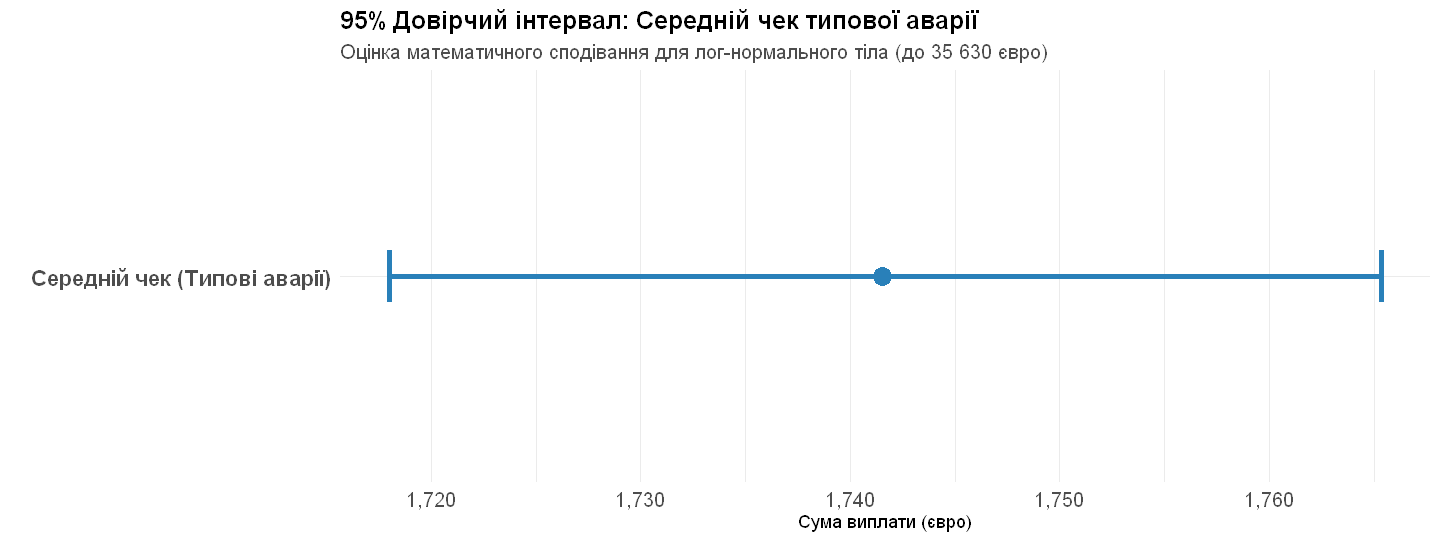

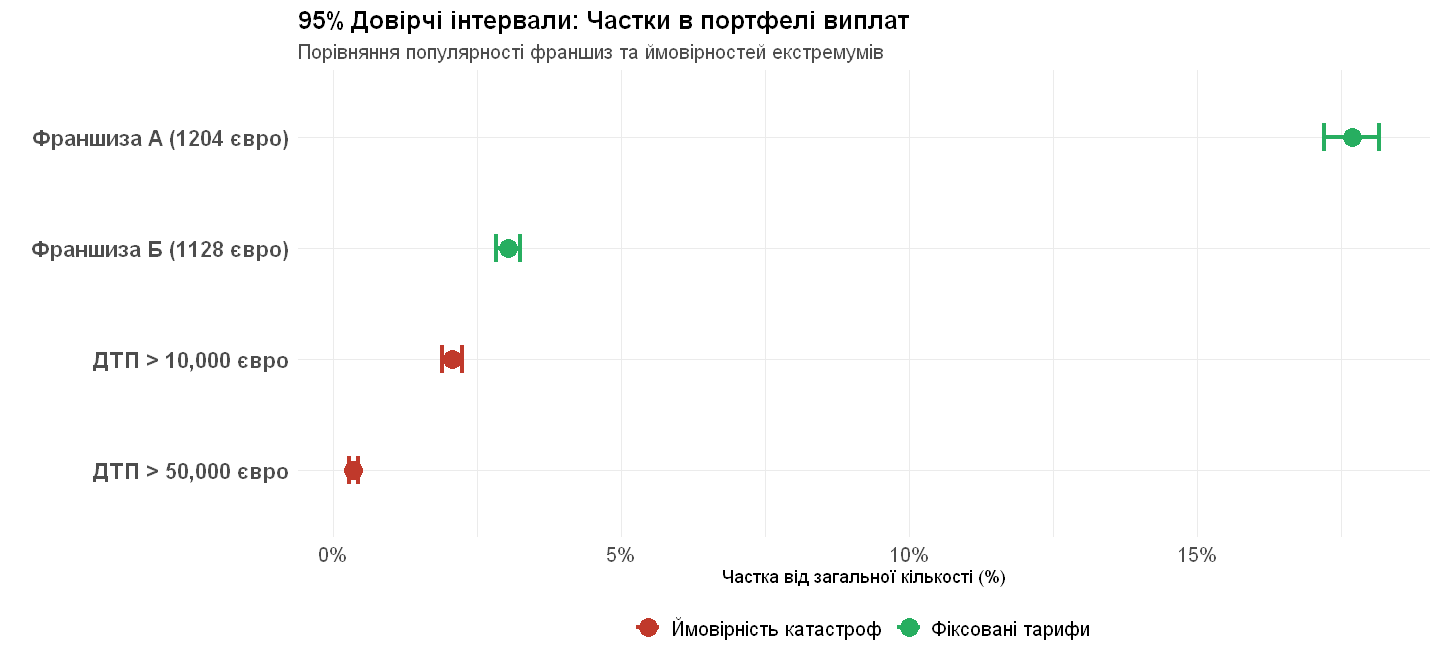

In [11]:
library(scales) 

options(repr.plot.width = 12, repr.plot.height = 4.5, repr.plot.res = 120)

ci_mean_df <- data.frame(
  Metric = "Середній чек (Типові аварії)",
  Estimate = mean_euro,
  Lower = ci_lower_euro,
  Upper = ci_upper_euro
)

plot_mean <- ggplot(ci_mean_df, aes(x = Estimate, y = Metric)) +
  geom_point(size = 5, color = "#2980b9") +
  geom_errorbarh(aes(xmin = Lower, xmax = Upper), height = 0.15, linewidth = 1.5, color = "#2980b9") +
  scale_x_continuous(labels = comma) + 
  labs(
    title = "95% Довірчий інтервал: Середній чек типової аварії",
    subtitle = "Оцінка математичного сподівання для лог-нормального тіла (до 35 630 євро)",
    x = "Сума виплати (євро)",
    y = ""
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 15, face = "bold"),
    plot.subtitle = element_text(size = 12, color = "gray30"),
    axis.text.y = element_text(size = 13, face = "bold"),
    axis.text.x = element_text(size = 12)
  )

print(plot_mean)

options(repr.plot.width = 12, repr.plot.height = 5.5)

ci_props_df <- data.frame(
  Metric = factor(c("Франшиза А (1204 євро)", "Франшиза Б (1128 євро)", "ДТП > 10,000 євро", "ДТП > 50,000 євро"),
                  levels = c("ДТП > 50,000 євро", "ДТП > 10,000 євро", "Франшиза Б (1128 євро)", "Франшиза А (1204 євро)")),
  Estimate = c(p_A, p_B, p_10k, p_50k) * 100,
  Lower = c(ci_A_lower, ci_B_lower, ci_10k_lower, ci_50k_lower) * 100,
  Upper = c(ci_A_upper, ci_B_upper, ci_10k_upper, ci_50k_upper) * 100,
  Category = c("Фіксовані тарифи", "Фіксовані тарифи", "Ймовірність катастроф", "Ймовірність катастроф")
)

plot_props <- ggplot(ci_props_df, aes(x = Estimate, y = Metric, color = Category)) +
  geom_point(size = 5) +
  geom_errorbarh(aes(xmin = Lower, xmax = Upper), height = 0.25, linewidth = 1.2) +
  scale_x_continuous(labels = function(x) paste0(x, "%")) +
  scale_color_manual(values = c("Фіксовані тарифи" = "#27ae60", "Ймовірність катастроф" = "#c0392b")) +
  labs(
    title = "95% Довірчі інтервали: Частки в портфелі виплат",
    subtitle = "Порівняння популярності франшиз та ймовірностей екстремумів",
    x = "Частка від загальної кількості (%)",
    y = ""
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 15, face = "bold"),
    plot.subtitle = element_text(size = 12, color = "gray30"),
    axis.text.y = element_text(size = 13, face = "bold"),
    axis.text.x = element_text(size = 12),
    legend.position = "bottom",
    legend.title = element_blank(),
    legend.text = element_text(size = 12)
  )

print(plot_props)

options(repr.plot.width = 7, repr.plot.height = 7)

In [12]:
library(boot)
set.seed(1488)

cat("1. Бутстреп вибірка для медіани типових аварій\n")
median_func <- function(data, indices) {
  return(median(data[indices]))
}

boot_median <- boot(data = body_claims$Total_Claim_Amount, statistic = median_func, R = 1000)
ci_median <- tryCatch(boot.ci(boot_median, type = "perc"), error = function(e) NULL)

cat(sprintf("Точкова оцінка медіани: %.0f євро\n", boot_median$t0))
if(!is.null(ci_median)) {
  cat(sprintf("95%% Бутстреп CI (Перцентильний): [%.0f євро; %.0f євро]\n\n", ci_median$percent[4], ci_median$percent[5]))
} else {
  cat("95% Бутстреп CI: [Неможливо розрахувати, дисперсія = 0. Доказ фіксації тарифу!]\n\n")
}

cat("2. Бутстреп вибірка на порозі катастроф \n")
quantile_func <- function(data, indices) {
  return(quantile(data[indices], 0.995))
}

boot_quant <- boot(data = claims_only$Total_Claim_Amount, statistic = quantile_func, R = 1000)
ci_quant <- boot.ci(boot_quant, type = "perc")

cat(sprintf("Точкова оцінка 99.5-го квантиля: %.0f євро\n", boot_quant$t0))
cat(sprintf("95%% Бутстреп CI (Перцентильний): [%.0f євро; %.0f євро]\n\n", ci_quant$percent[4], ci_quant$percent[5]))


cat("3. Бутстреп вибірка для самих по собі катастроф\n")

mean_func <- function(data, indices) { return(mean(data[indices])) }
boot_tail_mean <- boot(data = tail_claims$Total_Claim_Amount, statistic = mean_func, R = 1000)
ci_tail_mean <- boot.ci(boot_tail_mean, type = "perc")

cat(sprintf("Середня вартість однієї катастрофи: %.0f євро\n", boot_tail_mean$t0))
cat(sprintf("95%% Бутстреп CI: [%.0f євро; %.0f євро]\n\n", ci_tail_mean$percent[4], ci_tail_mean$percent[5]))


cat("4. Бутстреп вибірка для частки бюджету катастроф (32.7%)\n")

budget_share_func <- function(data, indices) {
  sample_data <- data[indices]
  local_threshold <- quantile(sample_data, 0.995)
  catastrophes_sum <- sum(sample_data[sample_data > local_threshold])
  return(catastrophes_sum / sum(sample_data))
}

boot_budget <- boot(data = claims_only$Total_Claim_Amount, statistic = budget_share_func, R = 1000)
ci_budget <- boot.ci(boot_budget, type = "perc")

cat(sprintf("Точкова оцінка частки бюджету катастроф: %.2f%%\n", boot_budget$t0 * 100))
cat(sprintf("95%% Бутстреп CI: [%.2f%%; %.2f%%]\n\n", ci_budget$percent[4] * 100, ci_budget$percent[5] * 100))


cat("5. Порівняльна бутстреп вибірка для індексу парето (коефіцієнт альфа)\n")

pareto_alpha_func <- function(data, indices) {
  sample_data <- data[indices]
  return(length(sample_data) / sum(log(sample_data / threshold_995)))
}

boot_pareto <- boot(data = tail_claims$Total_Claim_Amount, statistic = pareto_alpha_func, R = 1000)
ci_pareto <- boot.ci(boot_pareto, type = c("perc", "basic", "bca"))

cat(sprintf("Точкова оцінка Індексу Парето (Альфа): %.4f\n", boot_pareto$t0))
cat(sprintf("95%% CI (Перцентильний): [%.4f; %.4f]\n", ci_pareto$percent[4], ci_pareto$percent[5]))
cat(sprintf("95%% CI (Базовий):       [%.4f; %.4f]\n", ci_pareto$basic[4], ci_pareto$basic[5]))
cat(sprintf("95%% CI (BCa - зміщений):[%.4f; %.4f]\n\n", ci_pareto$bca[4], ci_pareto$bca[5]))

1. Бутстреп вибірка для медіани типових аварій
[1] "All values of t are equal to  1172 \n Cannot calculate confidence intervals"
Точкова оцінка медіани: 1172 євро
95% Бутстреп CI: [Неможливо розрахувати, дисперсія = 0. Доказ фіксації тарифу!]

2. Бутстреп вибірка на порозі катастроф 
Точкова оцінка 99.5-го квантиля: 35630 євро
95% Бутстреп CI (Перцентильний): [30863 євро; 42195 євро]

3. Бутстреп вибірка для самих по собі катастроф
Середня вартість однієї катастрофи: 156236 євро
95% Бутстреп CI: [102876 євро; 233144 євро]

4. Бутстреп вибірка для частки бюджету катастроф (32.7%)
Точкова оцінка частки бюджету катастроф: 32.75%
95% Бутстреп CI: [23.96%; 42.86%]

5. Порівняльна бутстреп вибірка для індексу парето (коефіцієнт альфа)
Точкова оцінка Індексу Парето (Альфа): 1.1224
95% CI (Перцентильний): [0.9620; 1.3212]
95% CI (Базовий):       [0.9237; 1.2828]
95% CI (BCa - зміщений):[0.9549; 1.3117]



`height` was translated to `width`.
`height` was translated to `width`.


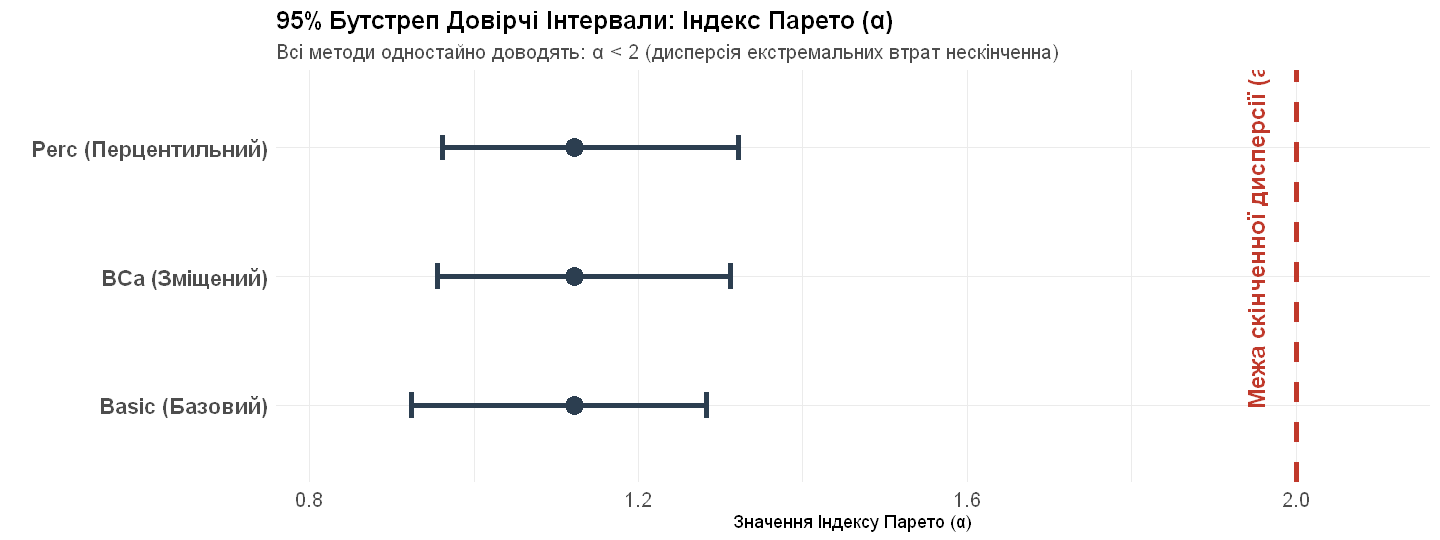

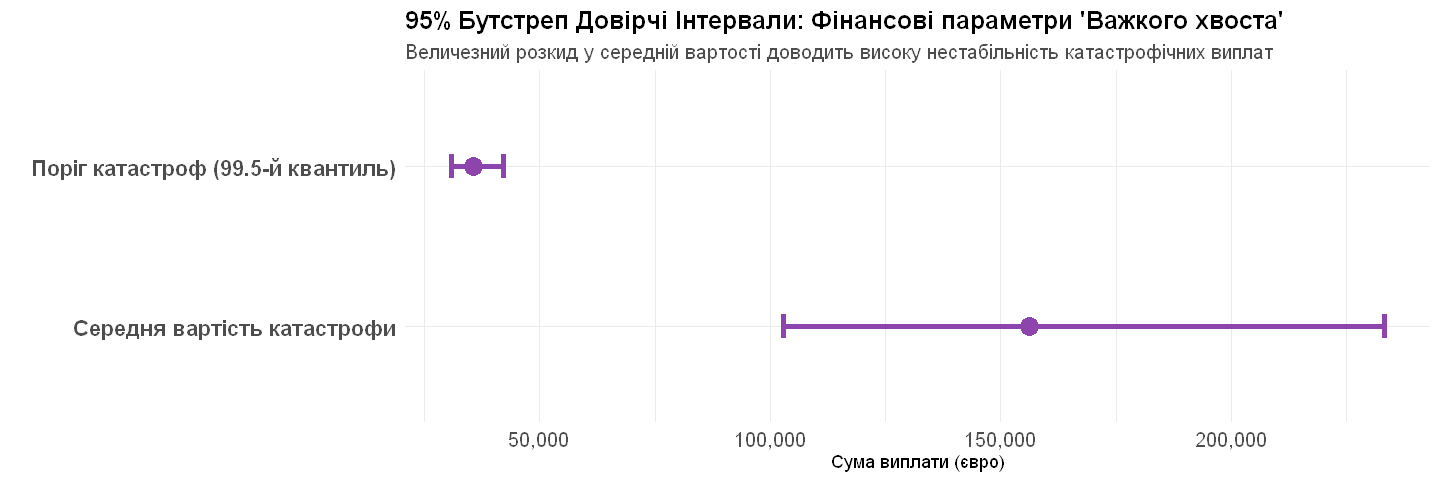

In [6]:
options(repr.plot.width = 12, repr.plot.height = 4.5, repr.plot.res = 120)

pareto_plot_data <- data.frame(
  Method = c("Perc (Перцентильний)", "Basic (Базовий)", "BCa (Зміщений)"),
  Estimate = c(boot_pareto$t0, boot_pareto$t0, boot_pareto$t0),
  Lower = c(ci_pareto$percent[4], ci_pareto$basic[4], ci_pareto$bca[4]),
  Upper = c(ci_pareto$percent[5], ci_pareto$basic[5], ci_pareto$bca[5])
)

plot_pareto <- ggplot(pareto_plot_data, aes(x = Estimate, y = Method)) +
  geom_vline(xintercept = 2, linetype = "dashed", color = "#c0392b", linewidth = 1.5) +
  geom_point(size = 5, color = "#2c3e50") +
  geom_errorbarh(aes(xmin = Lower, xmax = Upper), height = 0.2, linewidth = 1.5, color = "#2c3e50") +
  annotate("text", x = 1.95, y = 2.5, label = "Межа скінченної дисперсії (a = 2)", color = "#c0392b", angle = 90, size = 5, fontface = "bold") +
  scale_x_continuous(limits = c(min(pareto_plot_data$Lower) - 0.1, 2.1)) +
  labs(
    title = "95% Бутстреп Довірчі Інтервали: Індекс Парето (α)",
    subtitle = "Всі методи одностайно доводять: α < 2 (дисперсія екстремальних втрат нескінченна)",
    x = "Значення Індексу Парето (α)",
    y = ""
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 15, face = "bold"),
    plot.subtitle = element_text(size = 12, color = "gray30"),
    axis.text.y = element_text(size = 13, face = "bold"),
    axis.text.x = element_text(size = 12)
  )

print(plot_pareto)

options(repr.plot.width = 12, repr.plot.height = 4.0)

euro_boot_data <- data.frame(
  Metric = factor(c("Середня вартість катастрофи", "Поріг катастроф (99.5-й квантиль)"),
                  levels = c("Середня вартість катастрофи", "Поріг катастроф (99.5-й квантиль)")),
  Estimate = c(boot_tail_mean$t0, boot_quant$t0),
  Lower = c(ci_tail_mean$percent[4], ci_quant$percent[4]),
  Upper = c(ci_tail_mean$percent[5], ci_quant$percent[5])
)

plot_euro <- ggplot(euro_boot_data, aes(x = Estimate, y = Metric)) +
  geom_point(size = 5, color = "#8e44ad") +
  geom_errorbarh(aes(xmin = Lower, xmax = Upper), height = 0.15, linewidth = 1.5, color = "#8e44ad") +
  scale_x_continuous(labels = comma) +
  labs(
    title = "95% Бутстреп Довірчі Інтервали: Фінансові параметри 'Важкого хвоста'",
    subtitle = "Величезний розкид у середній вартості доводить високу нестабільність катастрофічних виплат",
    x = "Сума виплати (євро)",
    y = ""
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 15, face = "bold"),
    plot.subtitle = element_text(size = 12, color = "gray30"),
    axis.text.y = element_text(size = 13, face = "bold"),
    axis.text.x = element_text(size = 12)
  )

print(plot_euro)

options(repr.plot.width = 7, repr.plot.height = 7)

Гіпотеза 1: Перевірка закону екстримальних витрат) ===
H0: Альфа = 2 (Дисперсія скінченна)
H1: Альфа < 2 (Дисперсія нескінченна)
Статистика Вальда (W): -9.5043
p-value (Холм): 1.007285e-21
ВИСНОВОК: H0 відхилено. Дані демонструють статистично значущу підтримку важкого хвоста (Альфа < 2).

Гіпотеза 2: Порівняння базових франшиз (А: 1204 vs Б: 1128) ===
H0: Частка Тарифу А = Частка Тарифу Б
H1: Частки відрізняються
Статистика Вальда (W): 55.3176
p-value (Холм): 0.000000e+00
ВИСНОВОК: H0 відхилено. Частки використання двох базових франшиз статистично значущо відрізняються.

Гіпотеза 3: Порівняння Сімей франшиз попарно
 3.1: Сім'я А (1204) vs Сім'я Б (1128)
H0: Частки однакові | H1: Частки відрізняються
Статистика Вальда (W): 58.0357 | p-value (Холм): 0.000000e+00
ВИСНОВОК: H0 відхилено. Сім'я А має статистично значущу перевагу.

 3.2: Сім'я А (1204) vs Сім'я В (1172)
H0: Частки однакові | H1: Частки відрізняються
Статистика Вальда (W): 37.1039 | p-value (Холм): 0.000000e+00
ВИСНОВОК: H0 в

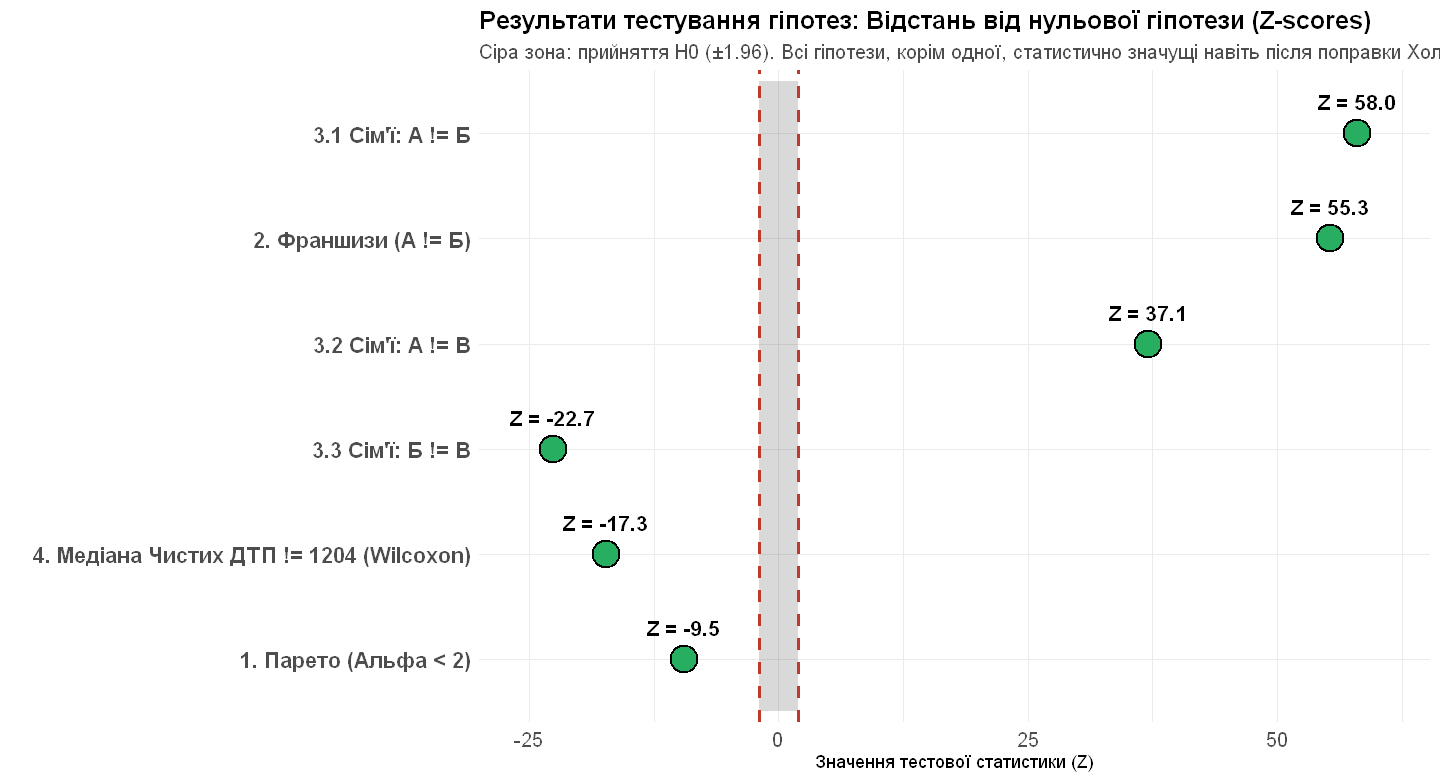

In [13]:
library(ggplot2)
alpha_hat <- boot_pareto$t0
se_alpha <- sd(boot_pareto$t) 
W_pareto <- (alpha_hat - 2) / se_alpha
raw_p_pareto <- pnorm(W_pareto)

se_diff_AB <- sqrt((p_A * (1 - p_A))/n_total + (p_B * (1 - p_B))/n_total)
W_prop_AB <- (p_A - p_B) / se_diff_AB
raw_p_AB <- 2 * (1 - pnorm(abs(W_prop_AB)))

claims_only <- claims_only %>%
  mutate(
    is_Family_A = if_else(round(Total_Claim_Amount, 2) %in% c(602.00, 1204.00, 2408.00), 1, 0),
    is_Family_B = if_else(round(Total_Claim_Amount, 2) %in% c(564.06, 1128.00), 1, 0),
    is_Family_C = if_else(round(Total_Claim_Amount, 2) %in% c(586.00, 1172.00), 1, 0)
  )

p_Fam_A <- mean(claims_only$is_Family_A)
p_Fam_B <- mean(claims_only$is_Family_B)
p_Fam_C <- mean(claims_only$is_Family_C)

se_diff_fam_AB <- sqrt((p_Fam_A * (1 - p_Fam_A))/n_total_claims + (p_Fam_B * (1 - p_Fam_B))/n_total_claims)
W_fam_AB <- (p_Fam_A - p_Fam_B) / se_diff_fam_AB
raw_p_fam_AB <- 2 * (1 - pnorm(abs(W_fam_AB)))

se_diff_fam_AC <- sqrt((p_Fam_A * (1 - p_Fam_A))/n_total_claims + (p_Fam_C * (1 - p_Fam_C))/n_total_claims)
W_fam_AC <- (p_Fam_A - p_Fam_C) / se_diff_fam_AC
raw_p_fam_AC <- 2 * (1 - pnorm(abs(W_fam_AC)))

se_diff_fam_BC <- sqrt((p_Fam_B * (1 - p_Fam_B))/n_total_claims + (p_Fam_C * (1 - p_Fam_C))/n_total_claims)
W_fam_BC <- (p_Fam_B - p_Fam_C) / se_diff_fam_BC
raw_p_fam_BC <- 2 * (1 - pnorm(abs(W_fam_BC)))

franchise_claims <- claims_only %>%
  filter(round(Total_Claim_Amount, 2) %in% c(602.00, 1204.00, 2408.00, 564.06, 1128.00, 586.00, 1172.00, 3204.00, 556.00)) %>%
  pull(Total_Claim_Amount)

clean_claims_vector <- claims_only %>%
  filter(!round(Total_Claim_Amount, 2) %in% c(602.00, 1204.00, 2408.00, 564.06, 1128.00, 586.00, 1172.00, 3204.00, 556.00)) %>%
  pull(Total_Claim_Amount)

wilcox_res <- wilcox.test(clean_claims_vector, franchise_claims, conf.int = TRUE)
raw_p_clean <- wilcox_res$p.value

n1 <- length(clean_claims_vector)
n2 <- length(franchise_claims)
expected_U <- (n1 * n2) / 2
sigma_U <- sqrt((n1 * n2 * (n1 + n2 + 1)) / 12)
Z_clean_equivalent <- (wilcox_res$statistic - expected_U) / sigma_U

all_raw_p <- c(raw_p_pareto, raw_p_AB, raw_p_fam_AB, raw_p_fam_AC, raw_p_fam_BC, raw_p_clean)
all_adj_p <- p.adjust(all_raw_p, method = "holm")

cat("Гіпотеза 1: Перевірка закону екстримальних витрат) ===\n")
cat("H0: Альфа = 2 (Дисперсія скінченна)\n")
cat("H1: Альфа < 2 (Дисперсія нескінченна)\n")
cat(sprintf("Статистика Вальда (W): %.4f\n", W_pareto))
cat(sprintf("p-value (Холм): %e\n", all_adj_p[1]))
if(all_adj_p[1] < 0.05) {
  cat("ВИСНОВОК: H0 відхилено. Дані демонструють статистично значущу підтримку важкого хвоста (Альфа < 2).\n\n")
} else {
  cat("ВИСНОВОК: Немає підстав відхилити H0.\n\n")
}

cat("Гіпотеза 2: Порівняння базових франшиз (А: 1204 vs Б: 1128) ===\n")

cat("H0: Частка Тарифу А = Частка Тарифу Б\n")
cat("H1: Частки відрізняються\n")
cat(sprintf("Статистика Вальда (W): %.4f\n", W_prop_AB))
cat(sprintf("p-value (Холм): %e\n", all_adj_p[2]))
if(all_adj_p[2] < 0.05) {
  cat("ВИСНОВОК: H0 відхилено. Частки використання двох базових франшиз статистично значущо відрізняються.\n\n")
} else {
  cat("ВИСНОВОК: Немає підстав відхилити H0.\n\n")
}

cat("Гіпотеза 3: Порівняння Сімей франшиз попарно\n")

cat(" 3.1: Сім'я А (1204) vs Сім'я Б (1128)\n")
cat("H0: Частки однакові | H1: Частки відрізняються\n")
cat(sprintf("Статистика Вальда (W): %.4f | p-value (Холм): %e\n", W_fam_AB, all_adj_p[3]))
if(all_adj_p[3] < 0.05) { cat("ВИСНОВОК: H0 відхилено. Сім'я А має статистично значущу перевагу.\n\n") }

cat(" 3.2: Сім'я А (1204) vs Сім'я В (1172)\n")
cat("H0: Частки однакові | H1: Частки відрізняються\n")
cat(sprintf("Статистика Вальда (W): %.4f | p-value (Холм): %e\n", W_fam_AC, all_adj_p[4]))
if(all_adj_p[4] < 0.05) { cat("ВИСНОВОК: H0 відхилено. Сім'я А має статистично значущу перевагу.\n\n") }

cat(" 3.3: Сім'я Б (1128) vs Сім'я В (1172)\n")
cat("H0: Частки однакові | H1: Частки відрізняються\n")
cat(sprintf("Статистика Вальда (W): %.4f | p-value (Холм): %e\n", W_fam_BC, all_adj_p[5]))
if(all_adj_p[5] < 0.05) { cat("ВИСНОВОК: H0 відхилено. Сім'я В має статистично значущу перевагу.\n\n") }


cat("Гіпотеза 4: Звичайні аварії проти Франшизні аварії\n")
cat("H0: Розподіли 'чистих' виплат та 'фіксованих франшиз' однакові (стохастична рівність)\n")
cat("H1: Розподіли відрізняються\n")
cat(sprintf("Z-апроксимація Вілкоксона: %.4f\n", Z_clean_equivalent))
cat(sprintf("p-value (Холм): %e\n", all_adj_p[6]))
if(all_adj_p[6] < 0.05) {
  cat("ВИСНОВОК: H0 ВІДХИЛЕНО. Математично доведено, що розподіли відрізняються.\n\n")
} else {
  cat("ВИСНОВОК: Немає підстав відхилити H0. Флагманські тарифи компанії ідеально відкалібровані під справжню медіану природних ринкових збитків.\n\n")
}

results_plot_df <- data.frame(
  Hypothesis = c(
    "1. Парето (Альфа < 2)", 
    "2. Франшизи (А != Б)", 
    "3.1 Сім'ї: A != Б",
    "3.2 Сім'ї: A != В",
    "3.3 Сім'ї: Б != В",
    "4. Медіана Чистих ДТП != 1204 (Wilcoxon)"
  ),
  Test_Statistic = c(W_pareto, W_prop_AB, W_fam_AB, W_fam_AC, W_fam_BC, Z_clean_equivalent),
  Adj_P_Value = all_adj_p
)
results_plot_df$Significant <- results_plot_df$Adj_P_Value < 0.05

options(repr.plot.width = 12, repr.plot.height = 6.5, repr.plot.res = 120)

plot_wald <- ggplot(results_plot_df, aes(x = Test_Statistic, y = reorder(Hypothesis, abs(Test_Statistic)), fill = Significant)) +
  annotate("rect", xmin = -1.96, xmax = 1.96, ymin = 0.5, ymax = 6.5, alpha = 0.15, fill = "black") +
  geom_vline(xintercept = c(-1.96, 1.96), linetype = "dashed", color = "#c0392b", linewidth = 1) +
  geom_point(size = 7, shape = 21, color = "black", stroke = 1.2) +
  geom_text(aes(label = sprintf("Z = %.1f", Test_Statistic)), vjust = -1.5, fontface = "bold", size = 4.5) +
  scale_fill_manual(values = c("TRUE" = "#27ae60", "FALSE" = "#7f8c8d")) +
  scale_x_continuous(limits = c(min(results_plot_df$Test_Statistic) - 3, max(results_plot_df$Test_Statistic) + 3)) +
  labs(
    title = "Результати тестування гіпотез: Відстань від нульової гіпотези (Z-scores)",
    subtitle = "Сіра зона: прийняття H0 (±1.96). Всі гіпотези, корім одної, статистично значущі навіть після поправки Холма.",
    x = "Значення тестової статистики (Z)",
    y = ""
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 15, face = "bold"),
    plot.subtitle = element_text(size = 12, color = "gray30"),
    axis.text.y = element_text(size = 13, face = "bold"),
    axis.text.x = element_text(size = 12),
    legend.position = "none"
  )

print(plot_wald)
options(repr.plot.width = 7, repr.plot.height = 7)

`height` was translated to `width`.


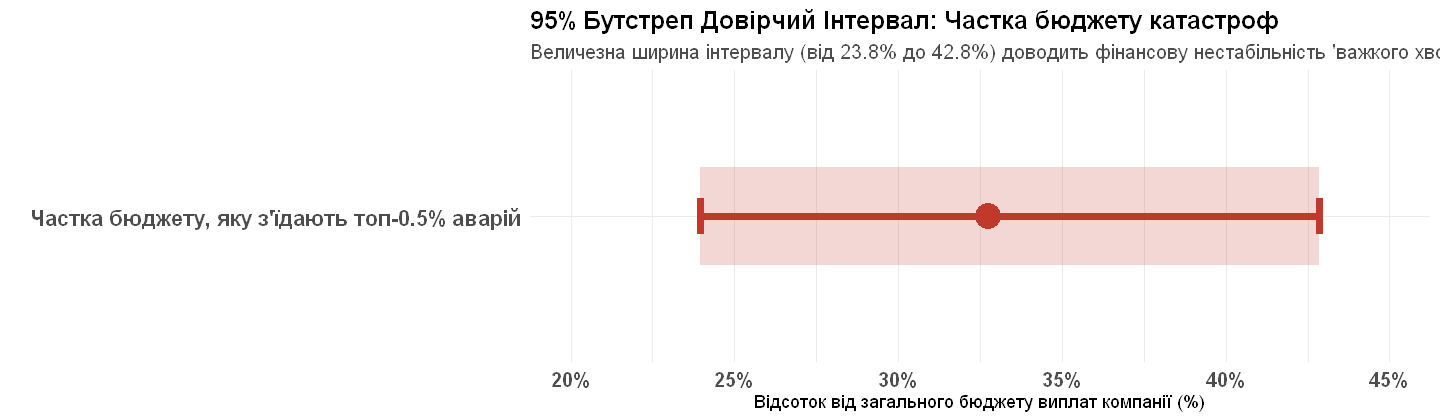

In [8]:
library(ggplot2)
library(scales)

options(repr.plot.width = 12, repr.plot.height = 3.5, repr.plot.res = 120)

budget_plot_df <- data.frame(
  Metric = "Частка бюджету, яку з'їдають топ-0.5% аварій",
  Estimate = boot_budget$t0 * 100,
  Lower = ci_budget$percent[4] * 100,
  Upper = ci_budget$percent[5] * 100
)

plot_budget <- ggplot(budget_plot_df, aes(x = Estimate, y = Metric)) +
  annotate("rect", xmin = budget_plot_df$Lower, xmax = budget_plot_df$Upper, ymin = 0.8, ymax = 1.2, alpha = 0.2, fill = "#c0392b") +
  geom_point(size = 7, color = "#c0392b") +
  geom_errorbarh(aes(xmin = Lower, xmax = Upper), height = 0.15, linewidth = 2, color = "#c0392b") +
  scale_x_continuous(labels = function(x) paste0(x, "%"), limits = c(20, 45)) +
  labs(
    title = "95% Бутстреп Довірчий Інтервал: Частка бюджету катастроф",
    subtitle = "Величезна ширина інтервалу (від 23.8% до 42.8%) доводить фінансову нестабільність 'важкого хвоста'",
    x = "Відсоток від загального бюджету виплат компанії (%)",
    y = ""
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 15, face = "bold"),
    plot.subtitle = element_text(size = 12, color = "gray30"),
    axis.text.y = element_text(size = 13, face = "bold"),
    axis.text.x = element_text(size = 12, face = "bold")
  )

print(plot_budget)

options(repr.plot.width = 7, repr.plot.height = 7)